# Student performance & placement — EDA

Dataset: [shambhurajejagadale/student-performance-prediction-dataset](https://www.kaggle.com/datasets/shambhurajejagadale/student-performance-prediction-dataset) (CSV: `student_dataset_10000_rows.csv`).

Goal: summarize behaviors and prior scores versus **exam_score** and **placement_status** for downstream prediction or for questions like which habits co-occur with placement.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import kagglehub
from IPython.display import display
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)

CSV_BASENAME = "student_dataset_10000_rows.csv"
KAGGLE_SLUG = "shambhurajejagadale/student-performance-prediction-dataset"

EXPECTED_COLS = [
    "study_hours",
    "attendance",
    "sleep_hours",
    "internet_usage",
    "assignments_completed",
    "previous_score",
    "exam_score",
    "placement_status",
]


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(CSV_BASENAME):
            assert p.is_file()
            return p
        cands = [p for p in kaggle_root.rglob("*.csv") if p.is_file()]
        if cands:
            p = max(cands, key=lambda x: x.stat().st_size)
            assert p.is_file()
            return p
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / CSV_BASENAME
    assert p.exists(), f"expected {CSV_BASENAME} under {root}"
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
missing = set(EXPECTED_COLS) - set(df.columns)
extra = set(df.columns) - set(EXPECTED_COLS)
assert not missing, f"missing columns: {sorted(missing)}"
assert not extra, f"unexpected columns: {sorted(extra)}"
assert df.shape[0] == 10_000
assert df.shape[1] == len(EXPECTED_COLS)

NUM_COLS = [c for c in df.columns if c != "placement_status"]
CAT_COLS = ["placement_status"]

print(df.shape[0], "rows ×", df.shape[1], "cols")
display(df.sample(5, random_state=7))
display(df.dtypes)


CSV: /kaggle/input/datasets/shambhurajejagadale/student-performance-prediction-dataset/student_dataset_10000_rows.csv
10000 rows × 8 cols


,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
1977,6,65,6,6,20,66,100.00,Placed
3880,8,50,8,3,14,67,100.00,Placed
52,4,100,6,8,15,44,100.00,Placed
2551,11,97,6,10,7,66,100.00,Placed
2246,6,95,9,2,8,38,94.64,Placed


study_hours                int64
attendance                 int64
sleep_hours                int64
internet_usage             int64
assignments_completed      int64
previous_score             int64
exam_score               float64
placement_status          object
dtype: object

## Univariate analysis

Per column: frequency table for **placement_status**; **FacetGrid** of histograms (KDE) for every numeric field so scales stay readable. Then `describe()` for numeric summaries.

For prediction: note the **Placed** vs **Not Placed** counts before choosing metrics (accuracy alone can dominate on the majority class).



=== placement_status ===


,count,pct
placement_status,,
Placed,8356,83.6
Not Placed,1644,16.4


,count,mean,std,min,25%,50%,75%,max
study_hours,10000.0,5.989600,3.163589,1.00,3.0000,6.00,9.0,11.0
attendance,10000.0,69.884600,17.616530,40.00,55.0000,70.00,85.0,100.0
sleep_hours,10000.0,6.498500,1.709354,4.00,5.0000,6.50,8.0,9.0
internet_usage,10000.0,6.062600,3.138163,1.00,3.0000,6.00,9.0,11.0
assignments_completed,10000.0,9.988400,6.034145,0.00,5.0000,10.00,15.0,20.0
previous_score,10000.0,64.911000,17.503020,35.00,50.0000,65.00,80.0,95.0
exam_score,10000.0,86.704207,15.058383,26.67,76.7275,92.12,100.0,100.0


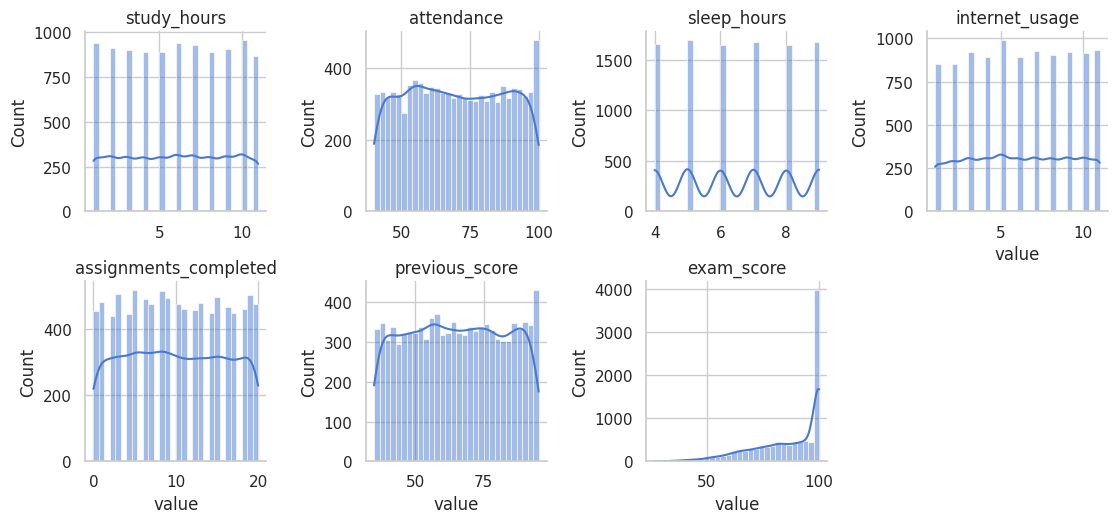

In [2]:
for col in CAT_COLS:
    vc = df[col].value_counts()
    tab = pd.DataFrame({"count": vc, "pct": (vc / len(df) * 100).round(1)})
    print(f"\n=== {col} ===")
    display(tab)

display(df[NUM_COLS].describe().T)

long = df[NUM_COLS].melt(var_name="metric", value_name="value")
g = sns.FacetGrid(long, col="metric", col_wrap=4, sharex=False, sharey=False, height=2.7, aspect=1.05)
g.map_dataframe(sns.histplot, x="value", kde=True, bins=30)
g.set_titles(col_template="{col_name}")
g.tight_layout()
plt.show()


### Univariate reflection

- **Placement** split: use the counts above when interpreting any model or chart — the negative class is smaller, so lift from habits will be easier to read with rates or PR curves than with raw counts alone.
- **Numeric shapes:** integer habits (study, sleep, internet, assignments) behave like scored scales; **exam_score** is continuous. Skew or stacking at round values informs whether tree models or linear models will fit cleanly.

_Connect to the objective_: if the target is **placement_status**, every numeric column is a candidate driver; if the target is **exam_score**, **previous_score** is the natural prior-performance peer.


## Multivariate analysis

- **Two numeric:** Pearson correlation heatmap among numeric columns; **lmplot** of **previous_score** vs **exam_score** with **placement_status** as `hue` to see whether slopes differ by outcome.
- **Categorical × categorical:** tertile **attendance_band** × **placement_status** — count crosstab with `scipy.stats.chi2_contingency`, plus row-% table.
- **Categorical × numeric:** boxplots for **exam_score**, **previous_score**, and **study_hours** by **placement_status**.
- **Feature dependence (nonlinear):** `sklearn.feature_selection.mutual_info_classif` ranks numerics vs **placement_status** (complements linear correlation).


χ²(attendance_band × placement) = 298.543, dof = 2, p = 1.486e-65


placement_status,Not Placed,Placed
attendance_band,,
low_attendance,849,2644
mid_attendance,508,2728
high_attendance,287,2984


Row % within attendance band


placement_status,Not Placed,Placed
attendance_band,,
low_attendance,24.3,75.7
mid_attendance,15.7,84.3
high_attendance,8.8,91.2


Mutual information (numeric → placement_status), higher = more dependent


,mutual_info
exam_score,0.446841
study_hours,0.093269
assignments_completed,0.040363
previous_score,0.022109
attendance,0.018580
internet_usage,0.010326
sleep_hours,0.003387


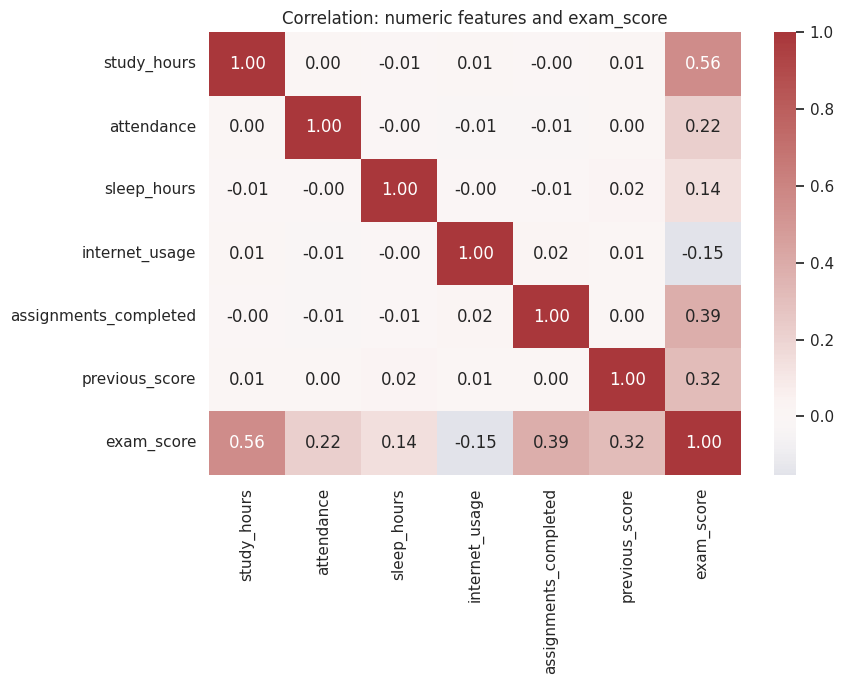

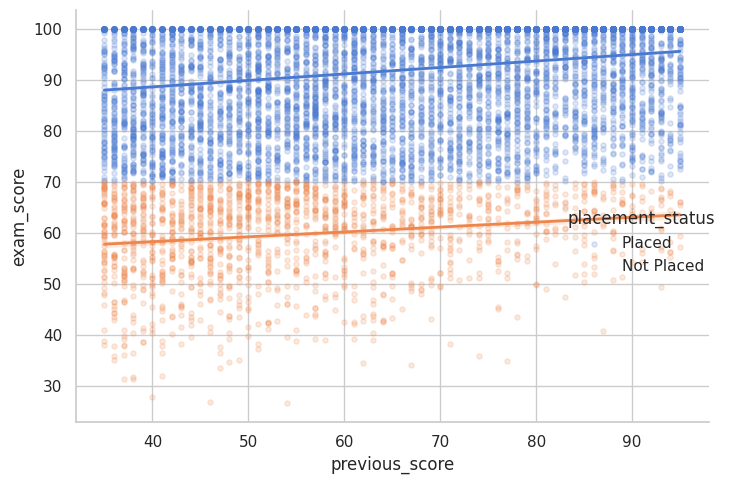

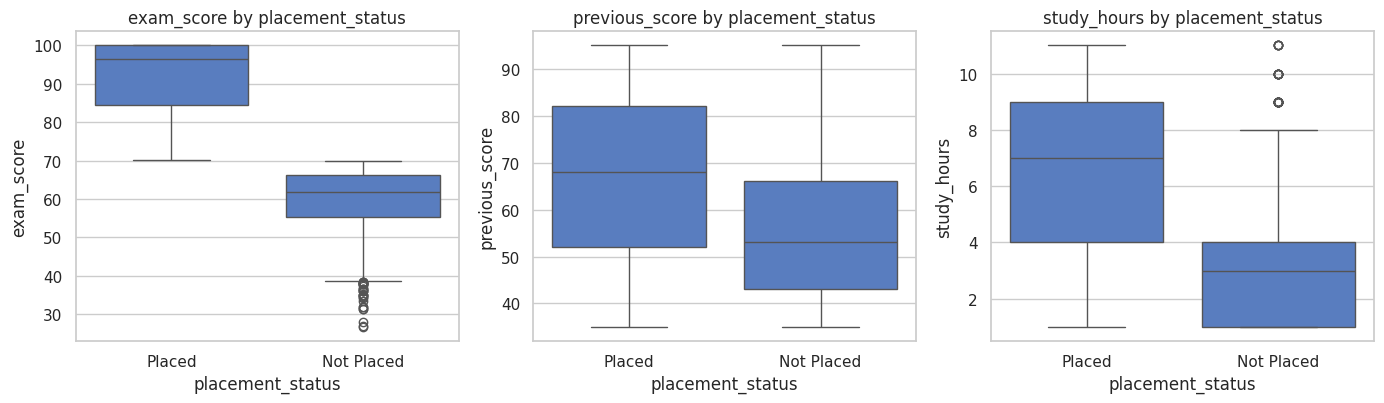

In [3]:
work = df.copy()
work["attendance_band"] = pd.qcut(
    work["attendance"], q=3, labels=["low_attendance", "mid_attendance", "high_attendance"]
)

ct_counts = pd.crosstab(work["attendance_band"], work["placement_status"])
chi2, p, dof, _expected = chi2_contingency(ct_counts)
print(f"χ²(attendance_band × placement) = {chi2:.3f}, dof = {dof}, p = {p:.3e}")
display(ct_counts)

ct_row_pct = pd.crosstab(work["attendance_band"], work["placement_status"], normalize="index") * 100
print("Row % within attendance band")
display(ct_row_pct.round(1))

le = LabelEncoder()
y_pl = le.fit_transform(work["placement_status"])
X_num = work[NUM_COLS].to_numpy()
mi = mutual_info_classif(X_num, y_pl, random_state=7)
mi_rank = pd.Series(mi, index=NUM_COLS).sort_values(ascending=False)
print("Mutual information (numeric → placement_status), higher = more dependent")
display(mi_rank.to_frame("mutual_info"))

corr = work[NUM_COLS].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation: numeric features and exam_score")
plt.tight_layout()
plt.show()

sns.lmplot(
    data=work,
    x="previous_score",
    y="exam_score",
    hue="placement_status",
    scatter_kws={"alpha": 0.18, "s": 14},
    line_kws={"linewidth": 2},
    height=5,
    aspect=1.15,
)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, col in zip(axes, ["exam_score", "previous_score", "study_hours"]):
    sns.boxplot(data=work, x="placement_status", y=col, ax=ax)
    ax.set_title(f"{col} by placement_status")
plt.tight_layout()
plt.show()


### Multivariate reflection

- **χ² test:** a small *p*-value supports that placement rates differ across attendance bands (not independent); use the row-% table to describe *how* rates shift between bands.
- **Correlations vs MI:** Pearson captures linear co-movement among numerics; mutual information can surface nonlinear alignment with **placement_status** — compare ranking to correlation with **exam_score**.
- **lmplot / boxplots:** separation in **exam_score** or **previous_score** by **placement_status** suggests signal for classifiers; overlapping boxes imply partial overlap typical of real placement data.

## Takeaways (for modeling)

- **Leakage check:** if **exam_score** is the prediction target, exclude it from features; if **placement_status** is the target, only include **exam_score** if it is known before placement in your real process.
- **Class imbalance:** stratified splits and metrics beyond accuracy (PR-AUC, recall on **Not Placed**) if catching non-placement matters.
- **Next steps:** baseline **LogisticRegression** or a tree model on numeric habits plus **previous_score**; validate whether **lmplot** slopes justify interaction terms.
